# Parameter recovery: is the δ_wide shift an artifact of the stimulus design? (Fig. S8)

Aggregates the parameter-recovery simulations produced by `simulate_data.py` into `derivatives/figures/model_recovery.pdf`.

Shows the distribution of recovered `delta_wide` for each generating value (1 = no shift, 2 = full range adaptation), separately for the two stimulus designs: the full design (narrow 10–25 vs. wide 10–40) and the censored design (both conditions restricted to 10–25).

**Warning:** `simulate_data.py` contained a bug (fixed 2026-08-10) where iterations after the first simulated from the *previous iteration's estimate* instead of the requested generating value. Simulation outputs generated before the fix should be regenerated before trusting this figure.

In [1]:
import numpy as np
from pathlib import Path

import pandas as pd
import seaborn as sns

In [2]:
# Search for all files like "subject-1_iteration-0_results.csv" in /data/ds-neuralpriors/simulated_recovery/delta_wide_*/design_*

bids_folder = Path('/data/ds-neuralpriors')
results_files = list(bids_folder.glob('simulated_recovery/delta_wide_*/design_*/iteration-*_results.csv'))

pars = pd.concat([pd.read_csv(f) for f in results_files], ignore_index=True)

# Get the design (full or censored) and delta_wide from the file path
pars['design'] = [f.parent.name.split('_')[-1] for f in results_files]

pars['gen_delta_wide'] = [f.parent.parent.name.split('_')[-1] for f in results_files]

pars['design'] = pars['design'].str.capitalize().map({'Full': 'Full (10-25 and 10-40)', 'Censored': 'Censored (All conditions 10-25)'})

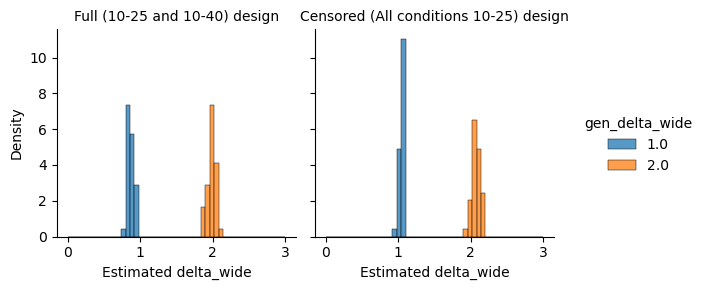

In [3]:
g = sns.FacetGrid(pars, col='design', hue='gen_delta_wide', margin_titles=True)

g.map(sns.histplot, 'delta_wide', stat='density', common_norm=False, bins=np.linspace(0, 3., 50))
g.add_legend()

# Make figur enicer
g.set_axis_labels('Estimated delta_wide', 'Density')
# Capitalize design names
g.set_titles(col_template='{col_name} design')

g.savefig('/data/ds-neuralpriors/derivatives/figures/model_recovery.pdf')